
User input string :  101

Number of bits :  3

f(x) = s.x for all possible x


f_array = [0, 1, 0, 1, 1, 0, 1, 0]


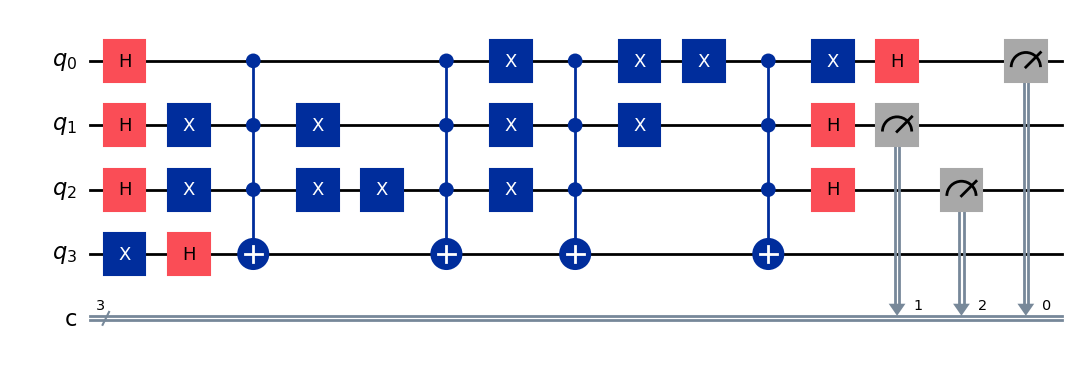

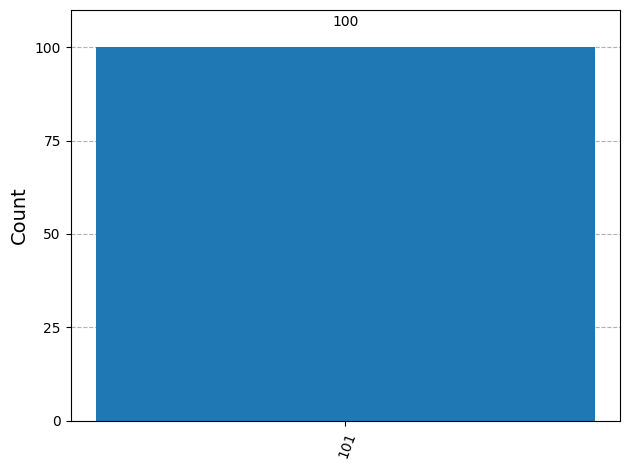


Counts: {'101': 100}

Measured bit string: 101

Algorithm correct: hidden string s recovered


In [7]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from numpy import pi
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random

bits_no = int(input("\nEnter no of bits(n): "))
string_s = str(input("\n Enter n-bit string"))

print("\nUser input string : ", string_s)
print("\nNumber of bits : ", bits_no)


N = 2**bits_no

f_array = []

for x in range(N):
    x_string = format(x, f"0{bits_no}b")

    dot_product = 0

    for i in range(bits_no):
        dot_product = dot_product + int(string_s[i]) * int(x_string[i])

    dot_product = dot_product % 2

    f_array.append(dot_product)

print("\nf(x) = s.x for all possible x\n")
print("\nf_array =", f_array)

# Creating the circuit

q_reg = QuantumRegister(bits_no + 1, "q")
c_reg = ClassicalRegister(bits_no, "c")

circuit_1 = QuantumCircuit(q_reg, c_reg)

# Ancilla last qubit = |1>
circuit_1.x(bits_no)

# Hadamard on all qubits
for i in range(bits_no + 1):
    circuit_1.h(i)

# Oracle from f_array

for x in range(N):
    if f_array[x] == 1:
        binary_x = format(x, f"0{bits_no}b")

        for i, bit in enumerate(reversed(binary_x)):
            if bit == '0':
                    circuit_1.x(i)

        circuit_1.mcx(list(range(bits_no)), bits_no)

        for i, bit in enumerate(reversed(binary_x)):
            if bit == '0':
                circuit_1.x(i)

# Hadamard again on input qubits only

for i in range(bits_no):
    circuit_1.h(i)

# Measure input qubits
circuit_1.measure(list(range(bits_no)), list(range(bits_no)))

display(circuit_1.draw(output="mpl"))

sim = AerSimulator()

result = sim.run(circuit_1, shots=100).result()

counts = result.get_counts()

counts = result.get_counts()

display(plot_histogram(counts))

print("\nCounts:", counts)

if len(counts) == 1:
    measured_output = list(counts.keys())[0]

    print("\nMeasured bit string:", measured_output)

    if measured_output == string_s:
        print("\nAlgorithm correct: hidden string s recovered")
    else:
        print("\nAlgorithm wrong: output does not match s")

else:
    print("\nAlgorithm not correct: more than one output appeared")
    print("Outputs obtained:", list(counts.keys()))
